In [1]:
#bm0

<b>Задание</b>
1. Познакомьтесь с данными.
2. Осуществите предобработку данных для дальнейшего исследования, обработайте аномалии.
3. Добавьте информацию из датасета region.csv.
4. Восстановите пропуски в столбце kitchen_area. 
5. Исследуйте рынок недвижимости в РФ за представленный период. Величина исследования - цена за м2. Обработайте аномалии.
6. Когда выгодно покупать/продавать объект недвижимости? 
7. Определите от каких признаков зависит стоимость объекта недвижимости. Найдите скрытые закономерности.
8. Выдвинете и проверьте собственную гипотезу статистическими методами.
9. Создайте модель прогноза цены объекта недвижимости.

## 1. Знакомство с данными

In [2]:
# Основа
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import datetime

# Прогнозированипе
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Для оформления
from matplotlib import font_manager as fm
from matplotlib import ticker
import matplotlib.dates as mdates
import locale
from cycler import cycler

In [3]:
locale.setlocale(locale.LC_TIME, 'russian')

'Russian_Russia.1251'

In [4]:
# Для визуализации
font_path = 'Arimo-Regular.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name

# Зададим глобальные настройки
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    # 'axes.spines.bottom': False,
    'axes.titlesize': 16,
    'axes.titleweight': 'medium',
    'axes.titlelocation': 'left',
    'axes.titlepad': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (10, 7.5),
    'axes.grid': False,
    'axes.labelpad': 10,
    'axes.labelcolor': '#ABABAB',
    'axes.prop_cycle': cycler(color=['#7D90D4', '#E478F0', '#71E09F', '#E07171', '#71CFE0']),
    'legend.fontsize': 14
})

# Зададим глобальные переменные для оформления
color = '#7D90D4'
padding = 3
bar_label = 12

In [5]:
realty = pd.read_csv('realty_18_21.csv')
regions = pd.read_csv('region.csv')

In [6]:
realty

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,81,3,13,14,2,60.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,3,1,8,17,4,93.2,13.8,11
5477002,12503160,2021-05-01,3,2,17,32,2,45.9,6.6,11
5477003,8800000,2021-05-01,2871,2,4,17,3,86.5,11.8,1
5477004,11831910,2021-05-01,3,1,8,33,2,52.1,18.9,11


In [7]:
realty.info()
print(50*'-')
regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   region         int64  
 3   building_type  int64  
 4   level          int64  
 5   levels         int64  
 6   rooms          int64  
 7   area           float64
 8   kitchen_area   float64
 9   object_type    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 417.9+ MB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      83 non-null     object
 1   reg_name  83 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [8]:
# Проверим пропуски
realty.isna().sum()

price                 0
date                  0
region                0
building_type         0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     253711
object_type           0
dtype: int64

In [9]:
# Проверим дубликаты
realty.duplicated().sum()

np.int64(235655)

<b>Выводы:</b>
1. Обработать тип столбца date
2. Обработать логику названий: вторичный рынок (1 -> 2) и первичный рынок (11 -> 1)
3. Обработать дубликаты
4. Обработать пропуски по столбцу kitchen_area

## 2. Добавим информацию из region.csv

In [10]:
# Так как Республика Крым имеет два кода региона, возьмем первый из них
regions[regions['code'] == '7873, 6937']

,code,reg_name
36,"7873, 6937",Республика Крым


In [11]:
# В таком случае заменим все вторые на первые 
realty['region'].replace(6937, 7873, inplace=True)

C:\Users\myras\AppData\Local\Temp\ipykernel_19344\352058547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  realty['region'].replace(6937, 7873, inplace=True)


In [12]:
# Исправим '7873, 6937', оставляя только первый код
regions['code'] = regions['code'].str.split(', ').apply(lambda x: x[0])

In [13]:
# Исправим тип данных столбца code
regions['code'] = regions['code'].astype(int)

In [14]:
realty = realty.merge(regions, how='left', left_on='region', right_on='code')

## 

## 2. Обработка данных

#### 1. Обработать тип столбца date

In [15]:
realty['date'] = pd.to_datetime(realty['date'], format='%Y-%m-%d')

#### 2. Обработать логику названий

In [16]:
realty['object_type'].replace(1, 2, inplace=True)
realty['object_type'].replace(11, 1, inplace=True)

C:\Users\myras\AppData\Local\Temp\ipykernel_19344\904958070.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  realty['object_type'].replace(1, 2, inplace=True)
C:\Users\myras\AppData\Local\Temp\ipykernel_19344\904958070.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

#### 3. Обработать дубликаты

In [17]:
realty = realty.drop_duplicates().reset_index(drop=True)

#### 4. Обработать аномалии

In [18]:
#bm2

In [19]:
# Аномалия 1: Этаж недвижимости больше числа этажей в доме
realty = realty.query('not level > levels')

In [20]:
# Аномалия 2: rooms = -2, когда минимум по документации -1 (~студия)
realty = realty.query('not rooms == -2')

In [21]:
# Аномалия 3: Площадь кухни больше общей площади недвижимости
realty = realty.query('kitchen_area < area')

In [22]:
# Заметим, что после исправления аномалии 3 все nan по столбцу kitchen_area были убраны
realty.isna().sum()

price            0
date             0
region           0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
code             0
reg_name         0
dtype: int64

In [23]:
# Аномалия 4: Отрицательные цены
print(realty['price'].min())

realty = realty.query('price >= 0')

-2144967296


####

#### 5. Обработать пропуски по столбцу kitchen_area:
- 5.1 Проверить условия для коэффициента корреляции Пирсона: определить наличие выбросов, нормальность распределения, типы переменных (столбцов)
- 5.2 Определить корреляцию Пирсона при выполнении всех условий (иначе применить коэффициент Спирмена/Кенделла)
- 5.3 Построить и оценить модель прогноза площади кухонь
- 5.4 Заполнить пропуски с помощью модели при высокой точности модели

---
<div align='center'>
<i>Пропуски были удалены после исправления аномалии 3, в то время как модель для прогноза была построена.<br>Оставим модель для прогноза площади на кухни на будущее</i>
</div>

---

##### 5.1 Проверим все условия

Определим исследуемые переменные:
- Интервальные: area, price, kitchen_area
- Порядковые: building_type, level, levels, object_type

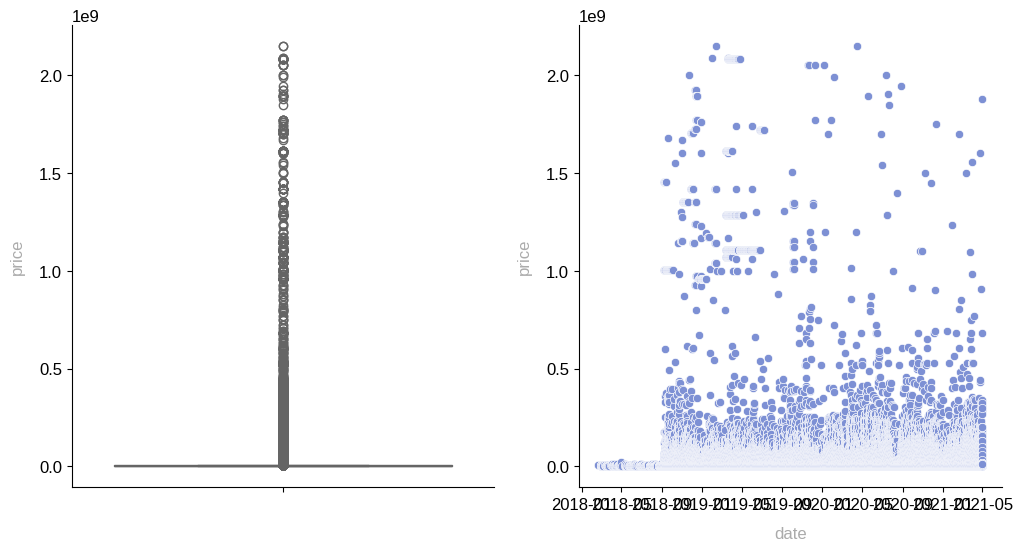

In [24]:
# Проверим наличие/отсутствие выбросов по столбцу price
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(realty['price'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=realty, x='date', y='price')

plt.show()

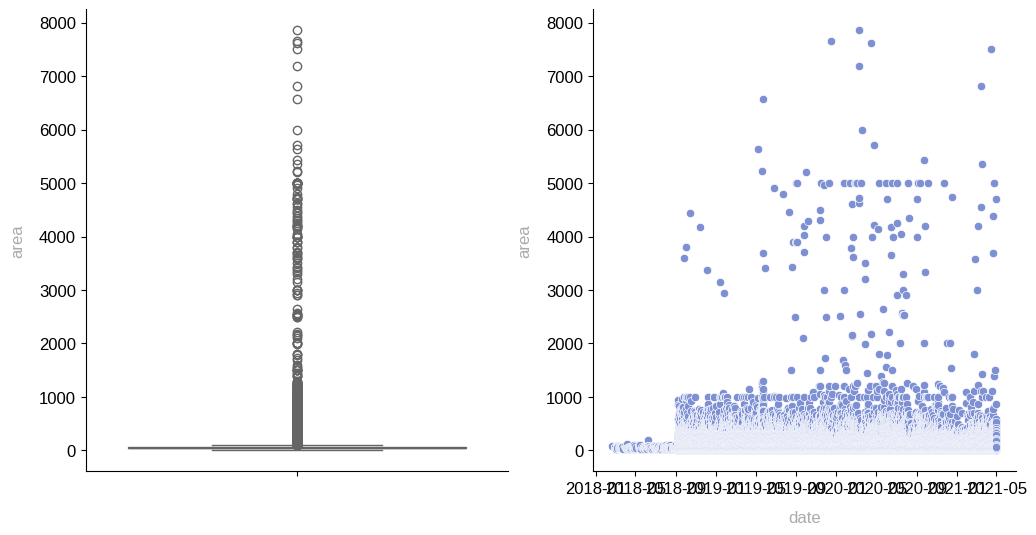

In [25]:
# Проверим наличие/отсутствие выбросов по столбцу area
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(realty['area'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=realty, x='date', y='area')

plt.show()

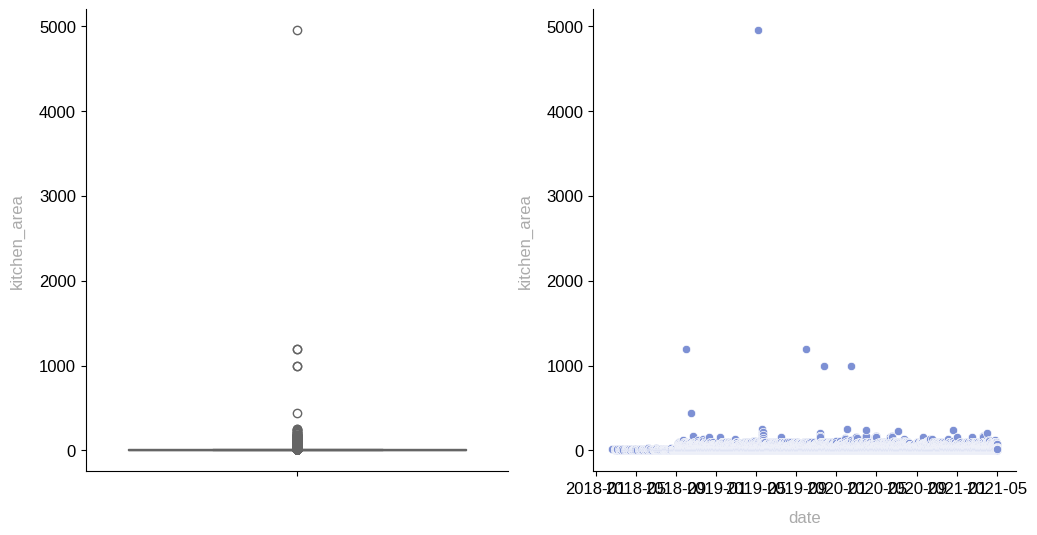

In [26]:
# Проверим наличие/отсутствие выбросов по столбцу kitchen_area
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(realty['kitchen_area'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=realty, x='date', y='kitchen_area')

plt.show()

<b>Вывод:</b> Видим наличие выбросов, перед обучением модели по прогнозу площади кухонь подготовим датасет

In [27]:
def ejection(data, col):
    q75 = np.percentile(data[col], 75)
    q25 = np.percentile(data[col], 25)
    iqr = q75 - q25
    ejection_h = q75 + 1.5 * iqr
    ejection_l  = q25 - 1.5 * iqr
    ejection_count = len(data[(data[col] < ejection_l) | (ejection_h < data[col])])
    ejection_perc = ejection_count / len(data) * 100
    
    return [ejection_h, ejection_l, ejection_count, ejection_perc]

In [28]:
# Создадим датасет без выбросов
good_realty = realty.copy()

for col in ['price', 'area', 'kitchen_area']:
    h_border, l_border = ejection(data=realty, col=col)[:2]
    
    good_realty = good_realty[(l_border <= good_realty[col]) & (good_realty[col] <= h_border)]

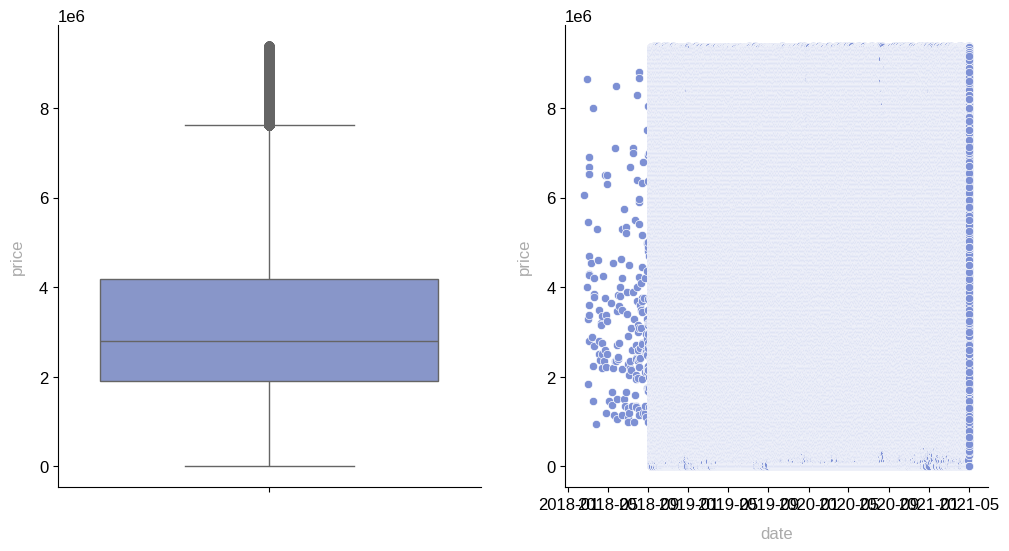

In [29]:
# Проверим вновь наличие/отсутствие выбросов по столбцу price
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(good_realty['price'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=good_realty, x='date', y='price')

plt.show()

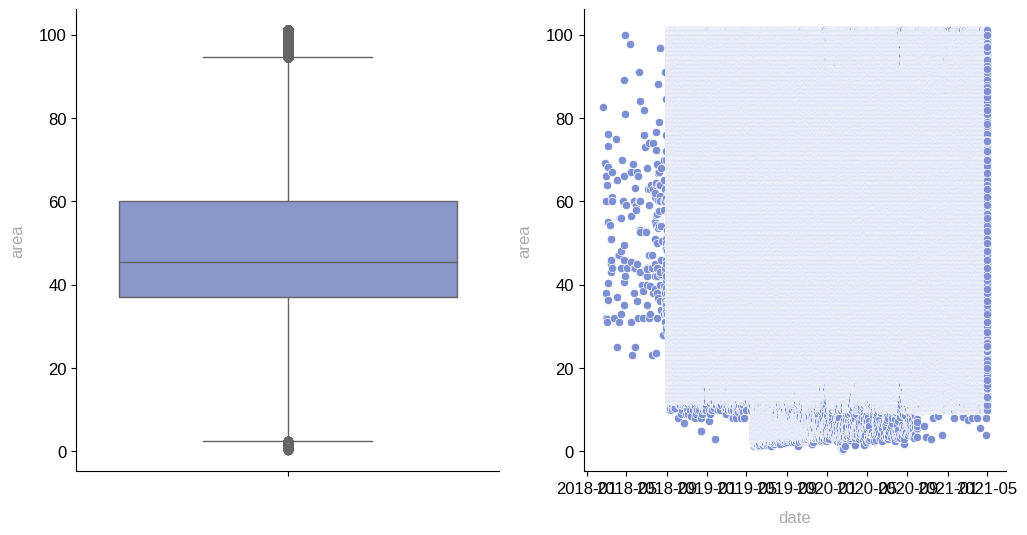

In [30]:
# Проверим наличие/отсутствие выбросов по столбцу area
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(good_realty['area'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=good_realty, x='date', y='area')

plt.show()

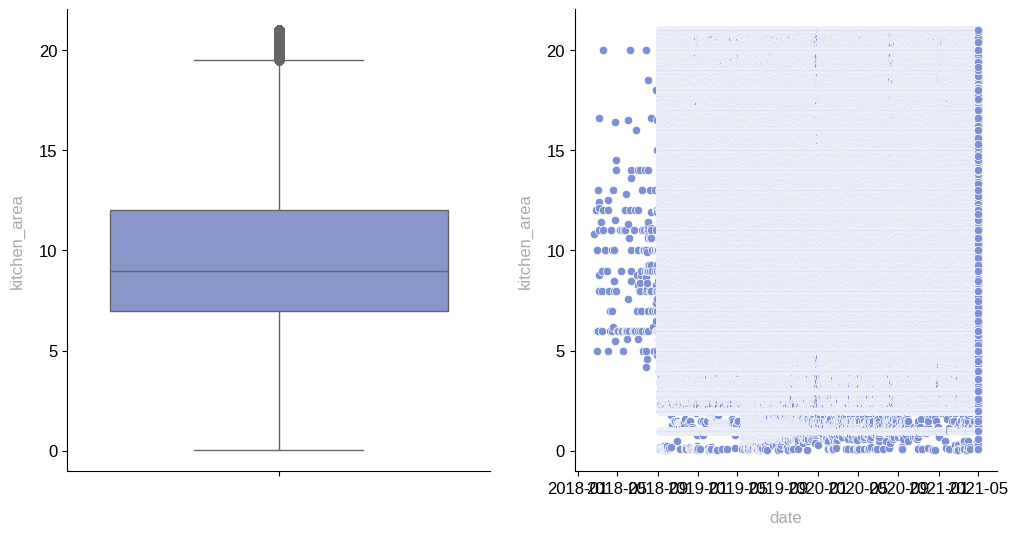

In [31]:
# Проверим наличие/отсутствие выбросов по столбцу kitchen_area
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(good_realty['kitchen_area'])

plt.subplot(1, 2, 2)
sns.scatterplot(data=good_realty, x='date', y='kitchen_area')

plt.show()

In [32]:
# Проверим остались ли отрицательные цены
good_realty['price'].min()

0

Отрицательных цен нет, однако минимальная стоимость недвижимости = 0. Такие цены в действительности то могут быть, если недвижимость была получена безвозмоздно, но для анализа общего рынка и построения модели прогноза площади кухонь такие цены не представляют пользы. Следовательно, возьмем минимальный квантиль c достойной ценой.

In [33]:
q1_price = np.percentile(good_realty['price'], 1)
q1_price

np.float64(700000.0)

In [34]:
good_realty = good_realty.query('price >= @q1_price')

Выбросы были исключены, теперь проверим нормальность распределения методом Q-Q plot

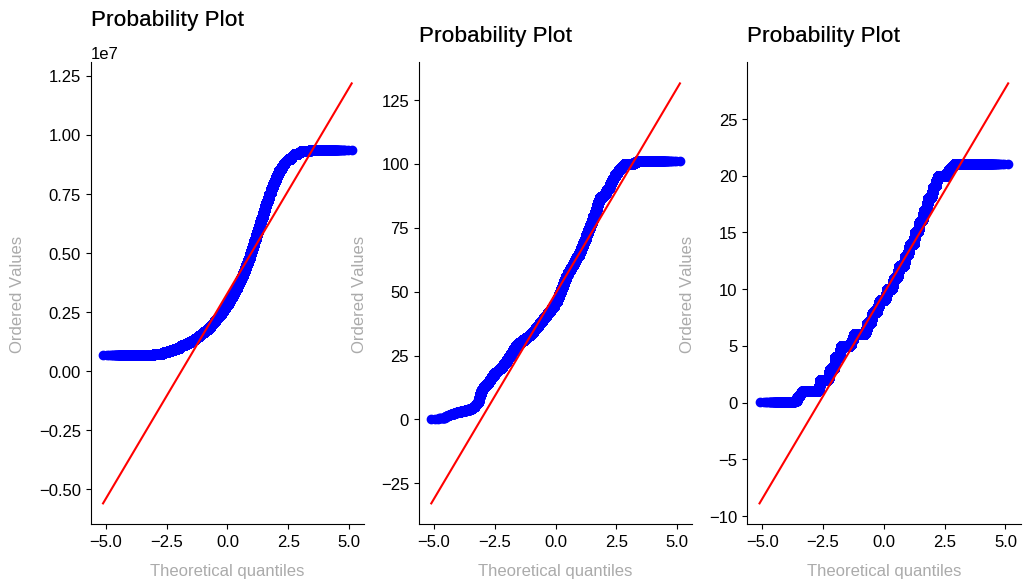

In [35]:
# Проверка нормальности распределения
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
st.probplot(good_realty['price'], dist='norm', plot=plt)

plt.subplot(1, 3, 2)
st.probplot(good_realty['area'], dist='norm', plot=plt)

plt.subplot(1, 3, 3)
st.probplot(good_realty['kitchen_area'], dist='norm', plot=plt)

plt.show()

В данных присутствует нарушение нормальности распределения, поэтому в дальнейшем при прогнозировании применим scaler

##### 5.2 Определить корреляцию переменных

<Axes: >

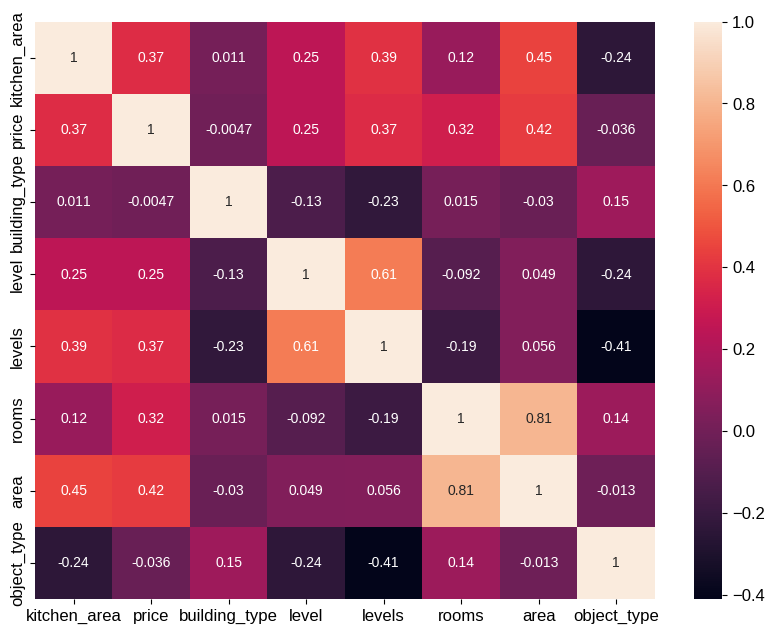

In [36]:
sns.heatmap(good_realty[['kitchen_area', 'price', 'building_type', 'level', 'levels', 'rooms', 'area', 'object_type']].corr(method='spearman'),
            annot=True)

<b>Выводы:</b>
- Переменные, наиболее представляющие интерес для включения в модель: price, area, levels
- Наблюдается мультиколлинеарность: между area и price, price и levels
 

##### 5.3 Построим модель линейной множественной регрессии

In [37]:
def pred_model_custom(data: pd.DataFrame, x_cols: list, y_col: str, model=LinearRegression(), scaler=None) -> list:

      # Разделим переменные для модели
      x = data[~data[y_col].isna()][x_cols]
      y = data[~data[y_col].isna()][y_col]

      # Разделим выборку на обучающую и тестовую
      x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=13)


      # Стандартизируем данные с помощью scaler
      scaler = scaler
      
      if scaler == None:
            x_train_st = x_train
            x_test_st = x_test
      
      else:
            x_train_st = scaler.fit_transform(x_train)
            x_test_st = scaler.transform(x_test)

      # Создадим и обучим линейную множественную модель
      model = model

      model.fit(x_train_st, y_train)

      # Прогноз значений
      y_pred = model.predict(x_test_st)

      # Оценка результатов
      r2 = r2_score(y_true=y_test, y_pred=y_pred)
      mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
      rmse = np.sqrt(mse)
      mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)

      print(f'r2: {r2}',
            f'mse: {mse}',
            f'rmse: {rmse}',
            f'mae: {mae}',
            sep='\n')
      
      return [y_pred, r2]

In [38]:
pred_model_custom(good_realty,
                  x_cols=['area', 'levels', 'price', 'object_type'],
                  y_col='kitchen_area',
                  model=Ridge(),
                  scaler=StandardScaler()
                  )

r2: 0.3219983752703527
mse: 9.178917246890066
rmse: 3.0296727953510203
mae: 2.3112535175007123


[array([8.29138806, 7.894799  , 8.75615331, ..., 7.59773196, 9.56352605,
        9.69082351]),
 0.3219983752703527]

##### * Попробуем еще улучшить точность прогноза

In [39]:
good_realty_encoded = pd.get_dummies(good_realty, columns=['rooms', 'object_type'], drop_first=True)

In [40]:
x_cols =['area', 'levels', 'price', *[f'rooms_{n}' for n in range(1, 10)], 'object_type_2']
x_cols

['area',
 'levels',
 'price',
 'rooms_1',
 'rooms_2',
 'rooms_3',
 'rooms_4',
 'rooms_5',
 'rooms_6',
 'rooms_7',
 'rooms_8',
 'rooms_9',
 'object_type_2']

In [41]:
pred_model_custom(good_realty_encoded,
                  x_cols=x_cols,
                  y_col='kitchen_area',
                  model=Ridge(),
                  scaler=StandardScaler()
                  )

r2: 0.4868668584057334
mse: 6.946895806051509
rmse: 2.6356964555979334
mae: 1.8752006699883326


[array([ 7.7155328 ,  4.86664396,  9.67429336, ...,  8.26838622,
        10.25957038, 10.86621613]),
 0.4868668584057334]

## 5. Исследование рынка недвижимости за представленный период
Исследуйте рынок недвижимости в РФ за представленный период. Величина исследования - цена за м2. Обработайте аномалии

---
<div align='center'>
<i>
<b>Примечания:</b><br>
    <br>
    1. Для получения агргированных показателей следует использовать датасет без выбросов: good_realty<br>
    2. Для нахождения фактов о необычных фактах по данным следует использовать датасет: realty
</i>
</div>

---

In [42]:
# Добавит столбец для сравнения (цена за м2)
good_realty['price_per_m2'] = (good_realty['price'] / good_realty['area']).round(1)

In [43]:
good_realty['month_year'] = good_realty['date'].dt.to_period('M').values.astype('datetime64[M]')

In [44]:
good_realty['day_name'] = good_realty['date'].dt.day_name(locale='russian')

In [45]:
good_realty['month_name'] = good_realty['date'].dt.month_name(locale='russian')

In [46]:
# Добавим название месяцев
month_eng_ru = {'January': 'Январь',
                'February': 'Февраль',
                'March': 'Март',
                'April': 'Апрель',
                'May': 'Май',
                'June': 'Июнь',
                'July': 'Июль',
                'August': 'Август',
                'September': 'Сентябрь',
                'October': 'Октябрь',
                'November': 'Ноябрь',
                'December': 'Декабрь',
                }

In [47]:
# Проверим аномалии, которые теоретически могли бы возникнуть
good_realty.query('price_per_m2 <= 1')

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,code,reg_name,price_per_m2,month_year,day_name,month_name


#### 5.1 Рассмотрим общую динамику

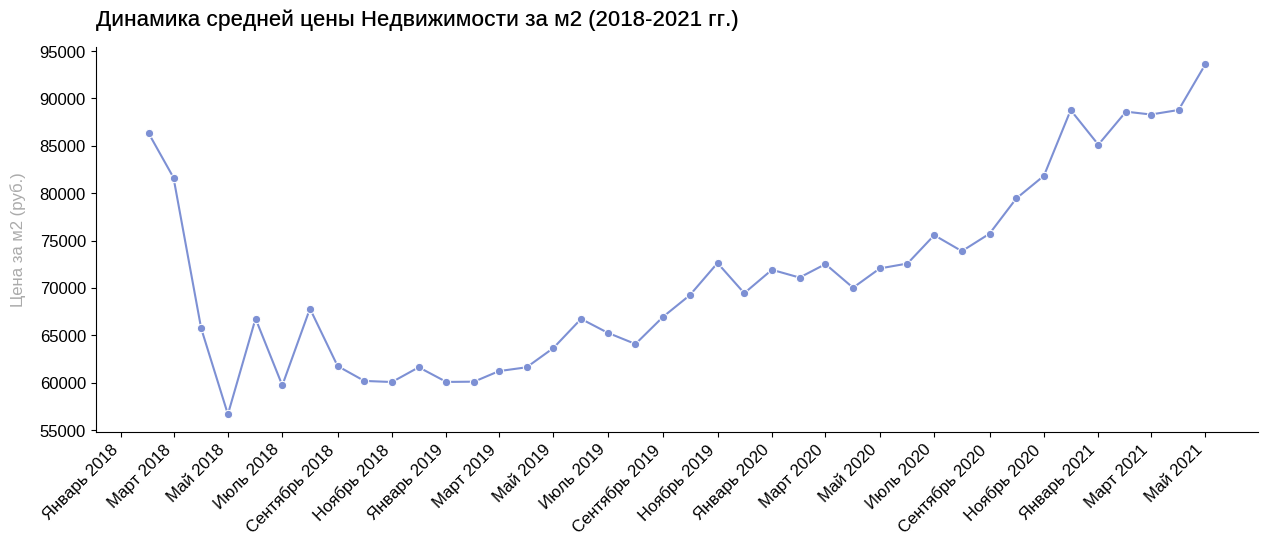

In [48]:
plt.figure(figsize=(15, 5))

ax = sns.lineplot(data=good_realty, x='month_year', y='price_per_m2', errorbar=None, marker='o')
ax.set(title='Динамика средней цены Недвижимости за м2 (2018-2021 гг.)',
       xlabel='',
       ylabel='Цена за м2 (руб.)',
       )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.show()

*#Доделать<br>*
Заметим сильные колебания средней цена за м2 в 2018 году. Следует выяснить, в связи с чем такая динамика. Оставим эту задачу на потом, а пока приблизим этот период.

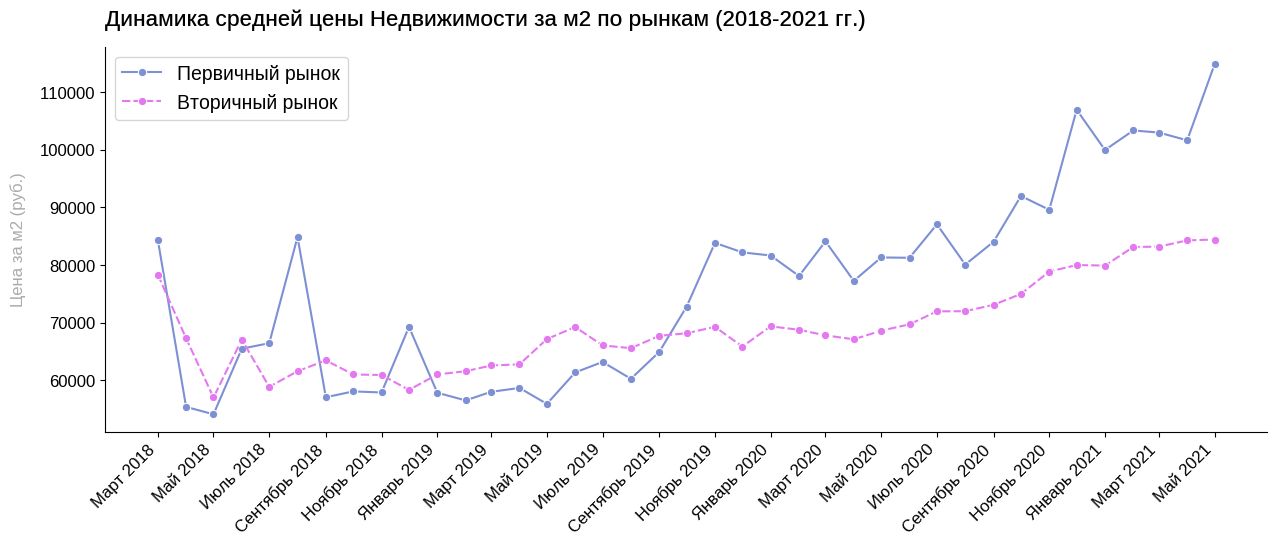

In [49]:
plt.figure(figsize=(15, 5))

report_511 = good_realty.pivot_table(index='month_year', columns='object_type', aggfunc={'price_per_m2': 'mean'}, values='price_per_m2')
report_511 = report_511[(~report_511[1].isna()) & (~report_511[2].isna())]
report_511.columns = ['Первичный рынок', 'Вторичный рынок']

ax = sns.lineplot(data=report_511, errorbar=None, marker='o')
ax.set(title='Динамика средней цены Недвижимости за м2 по рынкам (2018-2021 гг.)',
       xlabel='',
       ylabel='Цена за м2 (руб.)'
       )

plt.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

plt.show()

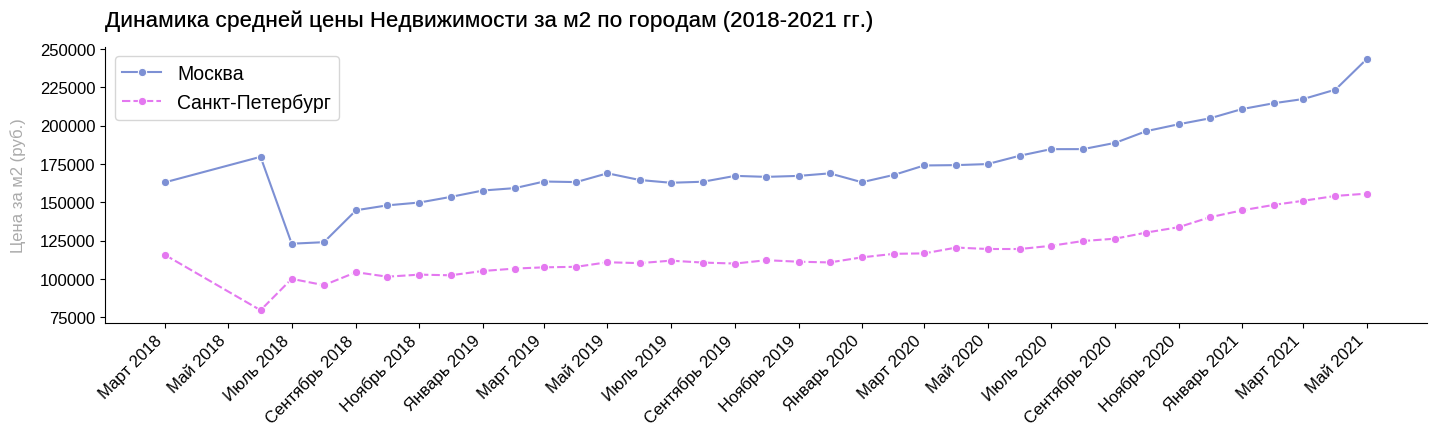

In [50]:
# Сравним динамику средней цена за м2 по ключевым городам России
mask_512 = '["Москва", "Санкт-Петербург"] in reg_name'

report_512 = good_realty.query(mask_512).pivot_table(index='month_year',
                                                   columns='reg_name',
                                                   aggfunc={'price_per_m2': 'mean'}, values='price_per_m2')

mask_512_nan = (~report_512['Москва'].isna()) & (~report_512['Санкт-Петербург'].isna())



plt.figure(figsize=(15, 5))

ax = sns.lineplot(data=report_512[mask_512_nan], errorbar=None, marker='o')
ax.set(title='Динамика средней цены Недвижимости за м2 по городам (2018-2021 гг.)',
       xlabel='',
       ylabel='Цена за м2 (руб.)'
       )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(pad=3)
plt.show()

#### 5.2 Исследование регионов на рынке недвижимости РФ

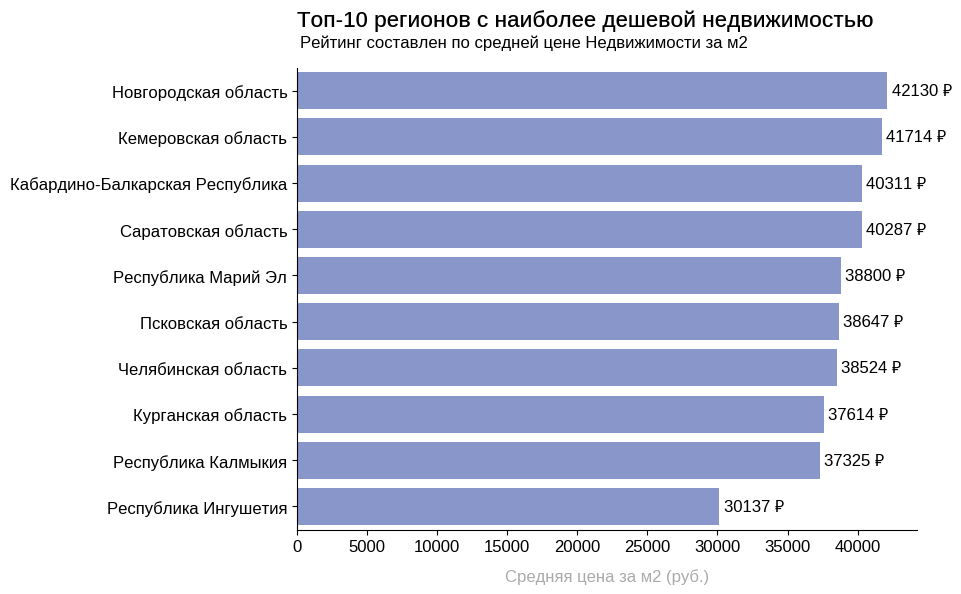

In [51]:
# Найдем топ-10 регионов с самой низкой средней стоимостью недвижимости за м2
report_521 = good_realty.pivot_table(index='reg_name',
                                     aggfunc={'price_per_m2': 'mean'},
                                     values='price_per_m2')\
                                         .sort_values(by='price_per_m2', ascending=False)\
                                         .reset_index()
                                         
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=report_521.tail(10), y='reg_name', x='price_per_m2', orient='h')
ax.set(xlabel='Средняя цена за м2 (руб.)',
       ylabel='',
       )
ax.bar_label(ax.containers[0], fmt='{:.0f} \u20BD', padding=padding, fontsize=bar_label)

plt.title(label='Топ-10 регионов с наиболее дешевой недвижимостью', pad=30)
plt.text(y=-0.95, x=200, s='Рейтинг составлен по средней цене Недвижимости за м2', fontsize=12)
plt.show()

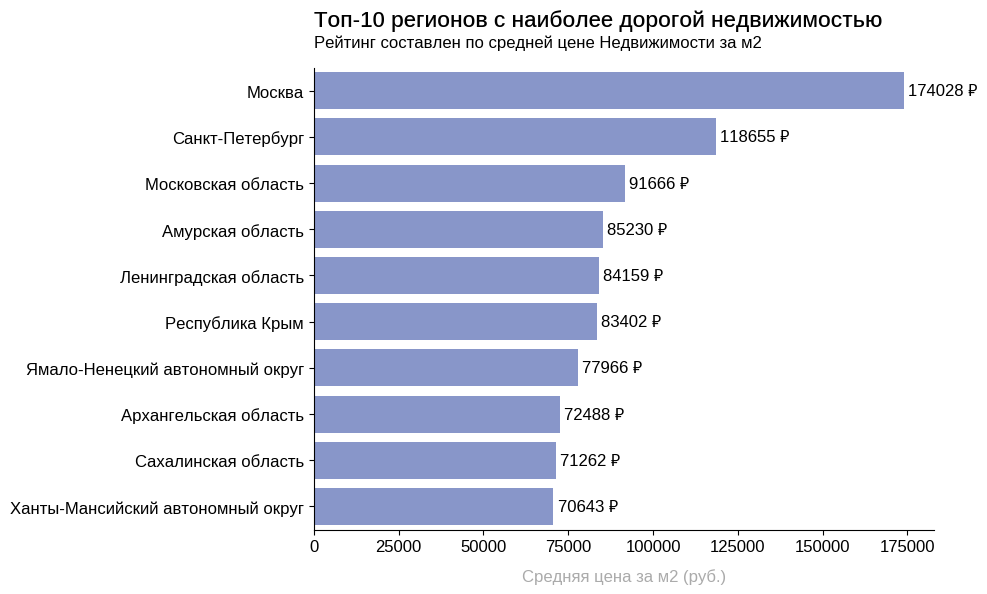

In [52]:
# Теперь топ-10 регионов с самой высокой средней стоимостью недвижимости за м
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=report_521.head(10), y='reg_name', x='price_per_m2', orient='h')
ax.set(xlabel='Средняя цена за м2 (руб.)',
       ylabel='',
       )
ax.bar_label(ax.containers[0], fmt='{:.0f} \u20BD', padding=padding, fontsize=bar_label)

plt.title(label='Топ-10 регионов с наиболее дорогой недвижимостью', pad=30)
plt.text(y=-0.95, x=200, s='Рейтинг составлен по средней цене Недвижимости за м2', fontsize=12)
plt.show()

building_type - Тип дома 0 - Другое. 1 - Панельный. 2 - Кирпично-монолитный. 3 - Кирпичный. 4 - Блочный 5 - Деревянный

In [53]:
building_name = {0: 'Другой',
                 1: 'Панельный',
                 2: 'Кирпично-монолитный',
                 3: 'Кирпичный',
                 4: 'Блочный',
                 5: 'Деревянный',
               }

good_realty['building_name'] = good_realty['building_type'].map(building_name)

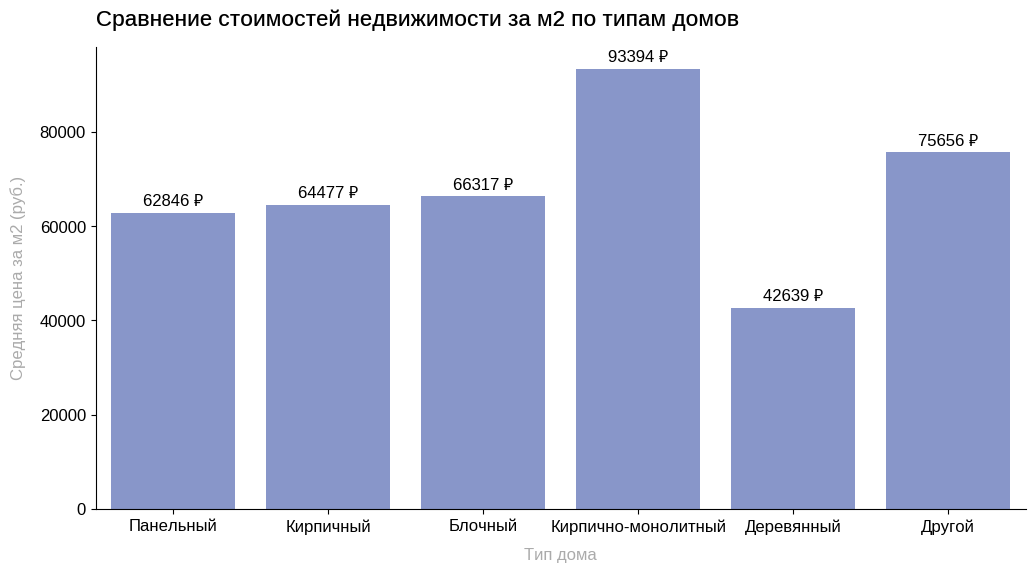

In [54]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=good_realty, x='building_name', y='price_per_m2', errorbar=None)
ax.set(title='Сравнение стоимостей недвижимости за м2 по типам домов',
       ylabel='Средняя цена за м2 (руб.)',
       xlabel='Тип дома',
       )
ax.bar_label(ax.containers[0], fmt='{:.0f} \u20BD', padding=padding, fontsize=bar_label)

plt.show()

(0.0, 200000.0)

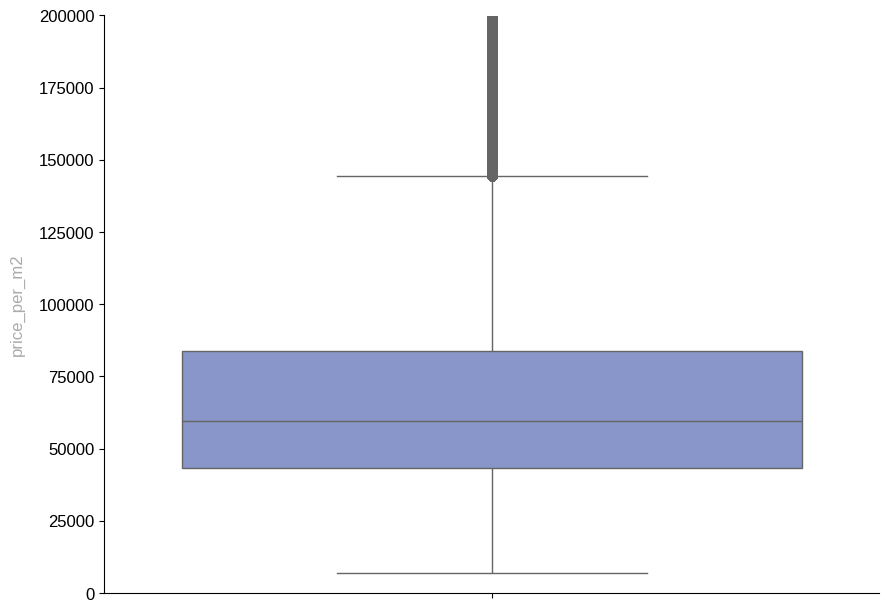

In [55]:
# Как видим выбросы есть и по вновь созданному столбцу
sns.boxplot(good_realty['price_per_m2'])

plt.ylim((0, 200000))

In [56]:
# Создадим новый датасет, без этих выбросов
ejection_price_per_m2 = ejection(good_realty, 'price_per_m2')
mask_ejection = (ejection_price_per_m2[1] <= good_realty['price_per_m2']) & (good_realty['price_per_m2'] <= ejection_price_per_m2[0])
good_realty2 = good_realty[mask_ejection]

In [57]:
min_price_per_m2 = good_realty2['price_per_m2'].min()
max_price_per_m2 = good_realty2['price_per_m2'].max()

good_realty2.query('[@min_price_per_m2, @max_price_per_m2] in price_per_m2')

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,code,reg_name,price_per_m2,month_year,day_name,month_name,building_name
194537,700000,2018-10-05,2871,3,5,5,1,100.0,15.0,2,2871,Нижегородская область,7000.0,2018-10-01,Пятница,Октябрь,Кирпичный
244708,700000,2018-10-12,3,5,1,1,2,100.0,8.0,2,3,Москва,7000.0,2018-10-01,Пятница,Октябрь,Деревянный
679640,700000,2018-12-12,2871,3,3,5,3,100.0,12.0,2,2871,Нижегородская область,7000.0,2018-12-01,Среда,Декабрь,Кирпичный
969831,700000,2019-01-29,1010,5,1,1,3,100.0,15.0,2,1010,Удмуртская Республика,7000.0,2019-01-01,Вторник,Январь,Деревянный
1253722,700000,2019-03-11,11991,3,2,3,2,100.0,12.0,2,11991,Карачаево-Черкесская Республика,7000.0,2019-03-01,Понедельник,Март,Кирпичный
3742704,3680000,2020-06-27,2661,3,2,24,-1,25.5,3.0,2,2661,Санкт-Петербург,144313.7,2020-06-01,Суббота,Июнь,Кирпичный
4706989,3680000,2021-01-16,2661,1,15,19,-1,25.5,3.0,2,2661,Санкт-Петербург,144313.7,2021-01-01,Суббота,Январь,Панельный


## 6. Когда выгодно покупать/продавать объект недвижимости? 

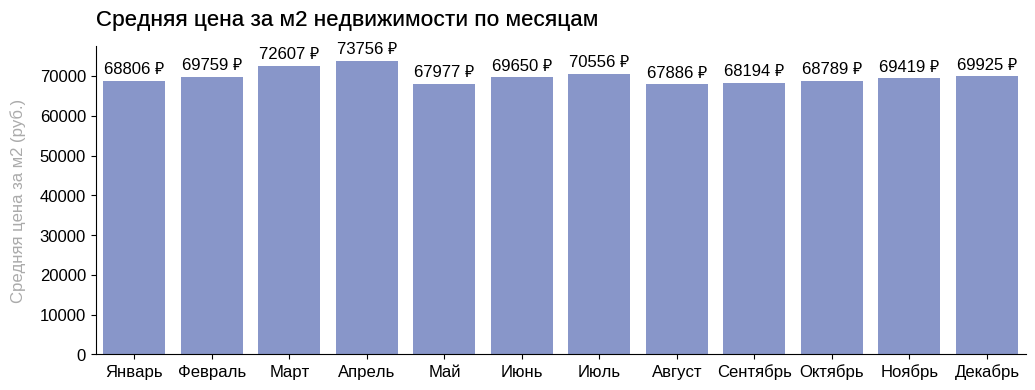

In [58]:
report_61 = good_realty.pivot_table(index='month_name',
                                     aggfunc={'price_per_m2': 'mean'},
                                     values='price_per_m2') \
                                         .reindex(month_eng_ru.values()) \
                                         .reset_index()

plt.figure(figsize=(12, 4))

ax = sns.barplot(data=report_61, x='month_name', y='price_per_m2', errorbar=None)
ax.set(title='Средняя цена за м2 недвижимости по месяцам',
       xlabel=None,
       ylabel='Средняя цена за м2 (руб.)'
       )

ax.bar_label(ax.containers[0], fmt='{:.0f} \u20BD', padding=padding, fontsize=bar_label)
plt.show()

In [59]:
season_dict = {'Декабрь': 'Зима',
               'Январь': 'Зима',
               'Февраль': 'Зима',
               'Март': 'Весна',
               'Апрель': 'Весна',
               'Май': 'Весна',
               'Июнь': 'Лето',
               'Июль': 'Лето',
               'Август': 'Лето',
               'Сентябрь': 'Осень',
               'Октябрь': 'Осень',
               'Ноябрь': 'Осень',
               }

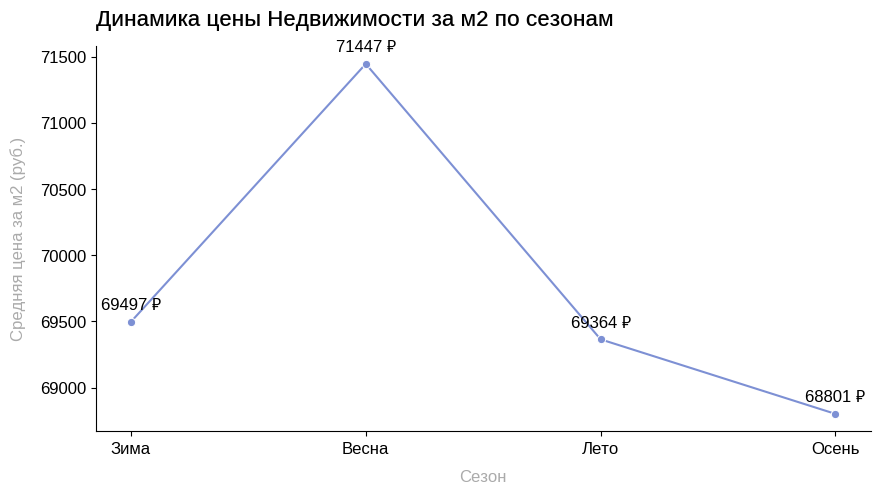

In [60]:
# Особой разницы между месяцами нет, агрегируем по сезонам
report_61 = good_realty.pivot_table(index='month_name',
                                     aggfunc={'price_per_m2': 'mean'},
                                     values='price_per_m2') \
                                         .reindex(month_eng_ru.values()) \
                                         .reset_index()
                                         
report_61['season'] = report_61['month_name'].map(season_dict)

seasons = ['Зима', 'Весна', 'Лето', 'Осень']
x_values = range(len(seasons))
y_values = report_61.groupby('season')['price_per_m2'].mean().reindex(seasons).values

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=report_61, x='season', y='price_per_m2', errorbar=None, marker='o')
ax.set(title='Динамика цены Недвижимости за м2 по сезонам',
       xlabel='Сезон',
       ylabel='Средняя цена за м2 (руб.)'
       )

for x, y in zip(x_values, y_values):
       plt.text(x, y*1.001, f'{round(y)} \u20BD', ha='center', va='bottom', fontsize=bar_label)


plt.show()

In [61]:
day_names = ['Понедельник',
             'Вторник',
             'Среда',
             'Четверг',
             'Пятница',
             'Суббота',
             'Воскресенье',
             ]

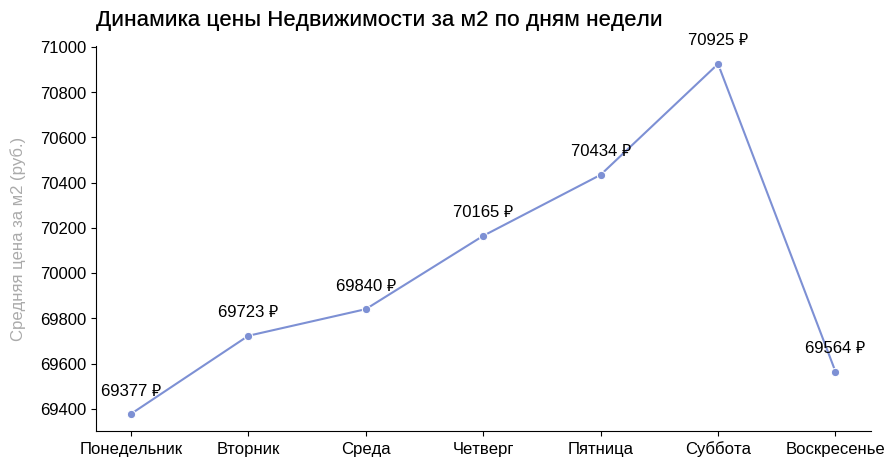

In [62]:
report_62 = good_realty.pivot_table(index='day_name',
                                     aggfunc={'price_per_m2': 'mean'},
                                     values='price_per_m2') \
                                         .reindex(day_names) \
                                         .reset_index()
x_values = range(len(day_names))
y_values = report_62['price_per_m2'].values                                         

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=report_62, x='day_name', y='price_per_m2', errorbar=None, marker='o')
ax.set(title='Динамика цены Недвижимости за м2 по дням недели',
       xlabel=None,
       ylabel='Средняя цена за м2 (руб.)'
       )

for x, y in zip(x_values, y_values):
       plt.text(x, y*1.001, f'{round(y)} \u20BD', ha='center', va='bottom', fontsize=bar_label)


plt.show()

## 7. Поиск зависимостей
Определите от каких признаков зависит стоимость объекта недвижимости. Найдите скрытые закономерности.

<Axes: >

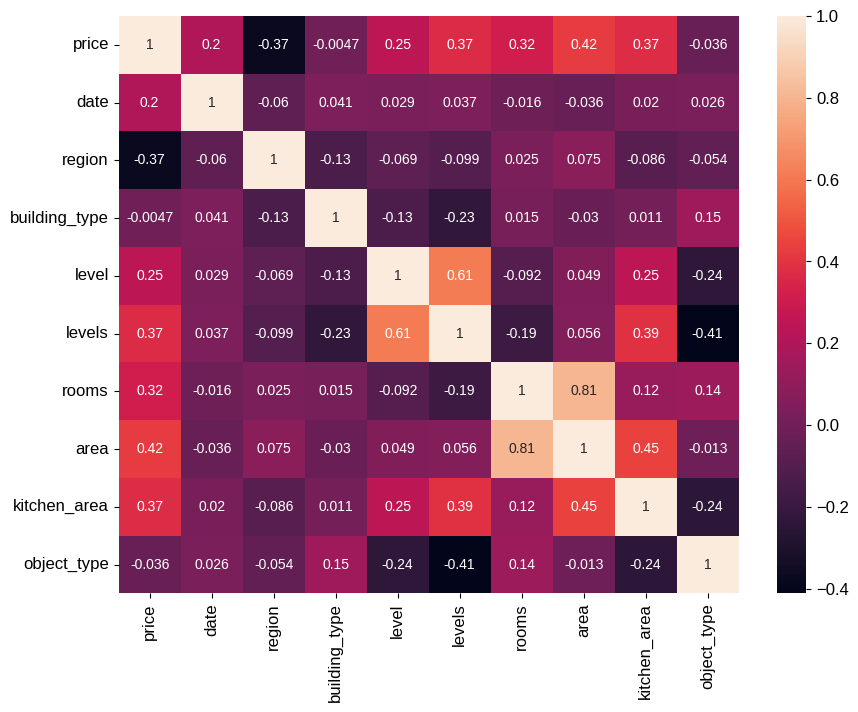

In [63]:
matrix_corr = good_realty.drop(columns=['reg_name', 'month_year', 'day_name', 'building_name', 'month_name', 'code', 'price_per_m2']).corr(method='spearman')

sns.heatmap(data=matrix_corr, annot=True)

<Axes: >

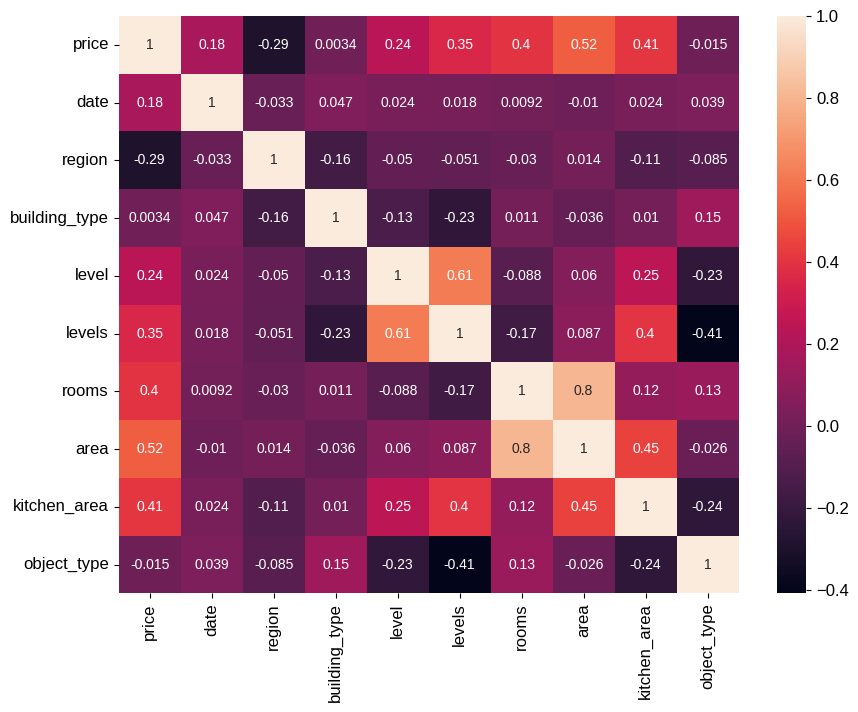

In [64]:
matrix_corr = good_realty2.drop(columns=['reg_name', 'month_year', 'day_name', 'building_name', 'code', 'price_per_m2', 'month_name']).corr(method='spearman')

sns.heatmap(data=matrix_corr, annot=True)

In [81]:
good_realty2_encoded = pd.get_dummies(good_realty2, columns=['building_type'], drop_first=True)

<Axes: >

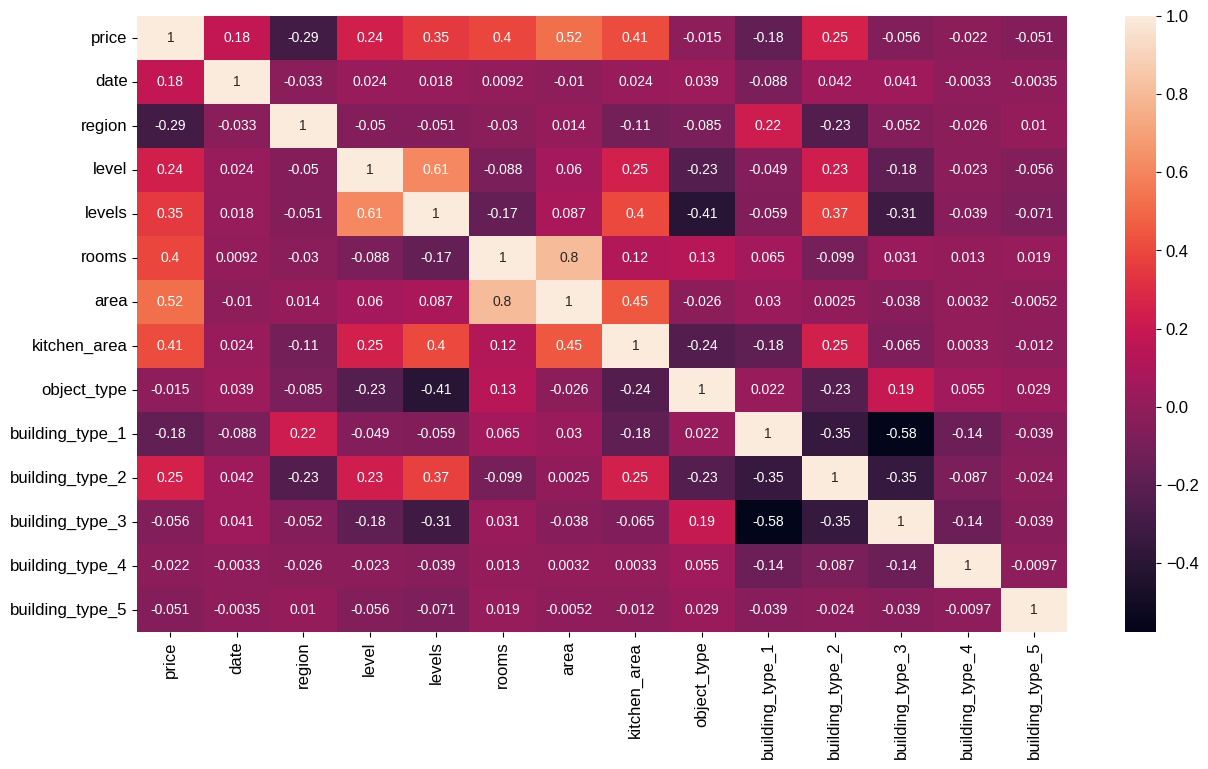

In [82]:
plt.figure(figsize=(15, 8))

matrix_corr = good_realty2_encoded.drop(columns=['reg_name', 'month_name', 'month_year', 'day_name', 'building_name', 'code', 'price_per_m2']).corr(method='spearman')

sns.heatmap(data=matrix_corr, annot=True)

## 8. Проверка гипотез
Выдвинете и проверьте собственную гипотезу статистическими методами.

<b>Определим гипотезы:</b>
- Разилия в средних ценах за м2 недвижимости по месяцам статистически незначимы

In [67]:
# Обозначим price_per_m2 как ppm2 и найдем общее среднее:
total_mean_ppm2 = good_realty['price_per_m2'].mean()

# Введем прочие необходимые переменные:
N = len(good_realty)
K = len(good_realty['month_name'].unique())
alpha = 0.05


In [68]:
# Для проверки первой гипотезы воспользуемя критерием Фишера:

# H0: Средние цена за м2 недвижимости по месяцам равны
# H1: Средние цена за м2 недвижимости по месяцам не равны

# Найдем внутригрупповую дисперсию
MS_wg = good_realty \
    .groupby('month_name')['price_per_m2'] \
    .apply(lambda group: sum((group - group.mean()) ** 2) ) \
    .sum() / (N - K)

# Найдем межгрупповую дисперсию
MS_bg = good_realty \
    .groupby('month_name')['price_per_m2'] \
    .apply(lambda group: len(group) * (group.mean() - total_mean_ppm2 ) ** 2 ) \
    .sum() / (K - 1) 

# Составим статистику и сравним
f_fact = MS_bg / MS_wg
f_crit = st.f.ppf(1 - alpha, K - 1, N - K)

if f_fact > f_crit:
    print(f'{f_fact} > {f_crit}: Следует отвергнуть нулевую гипотезу о равенстве средних по месяцам с вероятностью ошибки 5%')
    
else:
    print(f'{f_fact} < {f_crit}: Нет оснований отвергнуть нулевую гипотезу о равенстве средних по месяцам')


660.0526657054645 > 1.7886510484768523: Следует отвергнуть нулевую гипотезу о равенстве средних по месяцам с вероятностью ошибки 5%


## 9. Модель для прогнозирования цен
Создайте модель прогноза цены объекта недвижимости.

In [ ]:
# *[f'rooms_{n}' for n in range(1, 4)]

In [93]:
x_cols2 =['region', 'level', 'levels', 'area', 'kitchen_area', 'rooms', 'building_type_2', 'building_type_1']
x_cols2

['region',
 'level',
 'levels',
 'area',
 'kitchen_area',
 'rooms',
 'building_type_2',
 'building_type_1']

In [94]:
pred_model_custom(good_realty2_encoded,
                  x_cols=x_cols2,
                  y_col='price',
                  model=Ridge(),
                  scaler=StandardScaler()
                  )

r2: 0.4606875167809322
mse: 1446194139087.2905
rmse: 1202578.1218229819
mae: 931866.8366915418


[array([5520026.66419317, 3445723.94678536, 3340372.65158893, ...,
        2179185.55218455, 3873964.89441426, 4113117.93249733]),
 0.4606875167809322]

In [95]:
x_cols2 =['region', 'level', 'levels', 'area', 'kitchen_area', 'rooms', 'building_type']
x_cols2

['region', 'level', 'levels', 'area', 'kitchen_area', 'rooms', 'building_type']

In [96]:
pred_model_custom(good_realty2,
                  x_cols=x_cols2,
                  y_col='price',
                  model=Ridge(),
                  scaler=StandardScaler()
                  )

r2: 0.4537753823814713
mse: 1464729382694.8884
rmse: 1210260.047549653
mae: 941835.0264675495


[array([5485915.11526752, 3367095.11018892, 3120359.83610747, ...,
        1865462.69126225, 3722479.85303398, 3893001.13603647]),
 0.4537753823814713]